# **Concrete Strength Prediction**

## Author: Ridwan Ademola, IBRAHIM  
## Dataset link: https://www.kaggle.com/datasets/mchilamwar/predict-concrete-strength

---

### **Structure of Study**
- ✅ **Phase 1:** Data Cleaning  
- ✅ **Phase 2:** Exploratory Data Analysis
- ✅ **Phase 3:** Feature Engineering   
- ✅ **Phase 4:** Classical Machine Learning  
- ✅ **Phase 5:** Deep Learning  


### **Phase 1:** Data Cleaning
- ✅ Structure Checks  
- ✅ Missing Values
- ✅ Duplicates  
- ✅ Outliers Diagnostics  

**Import the Required Libraries**

In [5]:
#import pandas, numpy, matplotlib, seaborn and stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats

from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

#set seaborn style to "whitegrid."
sns.set(style = "whitegrid")

In [6]:
#Load the csv file into a DataFrame and view the first few datapoints
df = pd.read_csv("concrete_data.csv")

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [7]:
#Peep further into the data by checking the shape, null rows, datatypes, and general information
df.shape
df.isnull().sum()

df.dtypes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [8]:
#Check the statistical summary of the dataframe
df.describe()


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [9]:
#Check duplicate observations and drop them
df.duplicated().sum()
df = df.drop_duplicates()

#check shape of dataframe
df.shape

# Reset index after dropping
df = df.reset_index(drop = True)

In [34]:
#split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [84]:
#Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
#initialize the model
model = LinearRegression()

In [76]:
#train - fit data to model
model = model.fit(X_train_scaled,y_train)

In [77]:
#make predictions
y_pred = model.predict(X_test_scaled)

In [78]:
#calculate mse
mse = mean_squared_error(y_pred, y_test)
mse

70.03961594483539

In [79]:
#calculate mae
mae = mean_absolute_error(y_pred, y_test)
mae

6.409115734133303

In [80]:
#calculate rmse
rmse = root_mean_squared_error(y_pred, y_test)
rmse

8.368967436000418

In [81]:
#calculate r2
r_square= r2_score(y_pred, y_test)
r_square

0.6655434852070947

In [82]:
#put all metrics in a list
result = []

result.append(mse)
result.append(mae)
result.append(rmse)
result.append(r_square)
result

[70.03961594483539, 6.409115734133303, 8.368967436000418, 0.6655434852070947]

In [83]:
#put all metrics in a dictionary
result_dict = {}

result_dict["mse error"] = mse
result_dict["mae error"] = mae
result_dict["rmse error"] = rmse
result_dict["r-square error"] = r_square

result_dict

{'mse error': 70.03961594483539,
 'mae error': 6.409115734133303,
 'rmse error': 8.368967436000418,
 'r-square error': 0.6655434852070947}

In [85]:
#Create a function for reusability

#create a dictionary to put all models
All_model = {}

#create the function
def evaluation_model(model, X_train_scaled, X_test_scaled, y_train, y_test, model_name):

    #fit data to model
    model = model.fit(X_train_scaled,y_train)

    #make predictions
    y_pred = model.predict(X_test_scaled)

    #metrics
    mse = mean_squared_error(y_pred, y_test)
    mae = mean_absolute_error(y_pred, y_test)
    rmse = root_mean_squared_error(y_pred, y_test)
    r_square= r2_score(y_pred, y_test)

    #Put the metrics in a dictionary and then append it to all model dictionary
    All_model[model_name] = {
        "mse error": mse,
        "mae error": mae,
        "rmse error": rmse,
        "r-square error": r_square
    }

    #return the current model
    return All_model[model_name]

In [86]:
#try Linear Model
lin_model = LinearRegression()

lin_model = evaluation_model(lin_model, X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression")
lin_model

{'mse error': 70.03961594483539,
 'mae error': 6.409115734133303,
 'rmse error': 8.368967436000418,
 'r-square error': 0.6655434852070947}

In [87]:
#Check all models dictionary
All_model

{'Linear Regression': {'mse error': 70.03961594483539,
  'mae error': 6.409115734133303,
  'rmse error': 8.368967436000418,
  'r-square error': 0.6655434852070947}}

In [93]:
X = np.arange(0,31,1.5)
Y = [0, 9.76, 13.01, 11.39, 6.51, 0, -6.51, -11.39, -13.01, -9.76, 0, -4.56, -6.62, -6.64, -5.11, -2.49, 0.71, 4.05, 7.02, 9.16, 9.98]

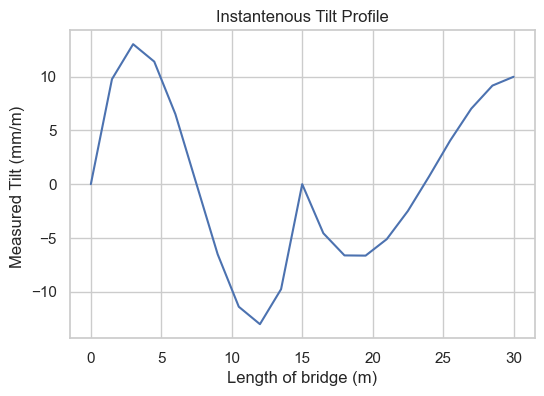

In [97]:
plt.figure(figsize = (6,4))
plt.plot(X,Y)
plt.xlabel("Length of bridge (m)")
plt.ylabel("Measured Tilt (mm/m) ")
plt.title("Instantenous Tilt Profile")
plt.show()